# LSPE-Strip: detection and removal of 1 Hz spikes
This notebook presents an analysis of periodic 1 Hz spikes appearing in the noise power spectra of data collected from the detectors of Strip polarimeters. 

It introduces two functions:  

- **`find_spikes`**: identifies periodic 1 Hz spikes within the power spectral density (PSD).  
- **`remove_spikes`**: removes the periodic signal in the time domain to produce cleaned spectra.  

The notebook applies these tools both to a toy model signal and to real detector data.



In [1]:
import striptease
from striptease import DataStorage, DataFile
from striptease import STRIP_BOARD_NAMES
from striptease import BOARD_TO_W_BAND_POL
from striptease import normalize_polarimeter_name
from striptease import get_polarimeter_index
from striptease import polarimeter_iterator
from striptease.biases import InstrumentBiases
from striptease import spectrum
from striptease import noise_generator

from importlib import reload
reload(spectrum)
reload(noise_generator)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl
import scipy.stats
import astropy
from astropy.io import ascii
from astropy.time import Time
from tqdm import tqdm
from scipy.optimize import curve_fit
import json

import pdb
import pickle
import os
import time
import re
import datetime
import math

import h5py
import sqlite3

/home/riccardo/.local/lib/python3.10/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [2]:
def double_dem(dem):
    
    n = (len(dem) // 2) * 2
    diff = (dem[0:n:2] - dem[1:n + 1:2])/2
    return diff

In [3]:
def total_pwr(pwr):
    
    n = (len(pwr) // 2) * 2
    avg = (pwr[0:n:2] + pwr[1:n + 1:2])/2
    return avg

In [4]:
def average_time(time):
    
    return (time[:-1:2] + time[1::2]) / 2

### `find_spikes` function 

This function automatically identifies the frequencies where spikes occur in a given PSD:

1. The input spectrum is divided into fixed frequency windows (`window_points`), and in each window a local trend is fitted in logarithmic space by linear regression.  
2. Residuals are computed by subtracting the fitted trend from the original data, flattening the noise baseline and preventing broad spectral features from being misinterpreted as spikes. The residual distribution is expected to be approximately Gaussian, with mean and standard deviation σ.  
3. Points whose residuals exceed the mean by more than `threshold_sigma` times σ are flagged as spikes, and their corresponding frequencies stored in the list `spike_freqs`.




In [5]:
def find_spikes(frequency, spectrum, window_points=50, threshold_sigma=5):
    
    #Final dictionary containing detected spike frequencies
    spike_freqs = []
    
    # Iterate over the spectrum using non-overlapping windows
    for i in range(0, len(frequency) - window_points, window_points):
        freq_win = frequency[i:i + window_points]
        spec_win = spectrum[i:i + window_points]

        # Convert to logarithmic scale to fit the spectral slope
        log_freq = np.log10(freq_win)
        log_spec = np.log10(spec_win)

        # Fit and remove the local spectral trend
        a, b = np.polyfit(log_freq, log_spec, 1)        
        drift = np.polyval([a, b], log_freq)            
        resid = log_spec - drift

        # Compute mean and standard deviation of residuals
        mean = np.mean(resid)
        std = np.std(resid)

        # Detect outliers above the sigma threshold
        for j in range(window_points):
            if resid[j] > mean + threshold_sigma * std:
                spike_freqs.append(freq_win[j])

    return spike_freqs

### `remove_spikes` function
Once the spike periodicity is known, this function is applied to the raw TOD to isolate and subtract the recurring spurious signal:

1. The raw data are divided into consecutive time windows of fixed duration (`window_sec`), corresponding to the period of the identified disturbance.  
2. The samples in each window are reshaped and averaged, producing the mean spike waveform (`spike_avg`) that represents the typical recurring pattern.  
3. The baseline level of the averaged waveform is estimated using the median and removed, ensuring that the off-spike region is centered around zero.
4. The spike profile is fitted with a smoothed square pulse model (`square_smooth`), initialized using parameters derived from the averaged waveform (amplitude, temporal position and width).
5. The fitted waveform (`spike_fit`) is replicated along the full time series and subtracted from the original TOD, obtaining the cleaned signal (`data_cleaned`).

In [6]:
def remove_spikes(data, time, window_sec):
    
    # Define window parameters
    dt = np.mean(np.diff(time))                 # Average sampling time interval
    n_samples = int(np.round(window_sec / dt))  # Number of samples per window
    n_windows = int(len(data) / n_samples)      # Number of windows

    # Compute the average spike pattern in a window
    spike = data[:n_windows * n_samples].reshape((n_windows, n_samples)) # Reshape data
    spike_avg = np.mean(spike, axis=0)                                   # Average over all windows
    baseline = np.median(spike_avg)                                      # Estimate baseline level
    spike_avg -= baseline                                                # Remove baseline
    
    time_window = np.linspace(0, window_sec, n_samples, endpoint=False)
    
    # Initial guess
    A = np.max(spike_avg) - np.min(spike_avg)       # Spike amplitude
    t0 = time_window[np.argmax(np.abs(spike_avg))]  # Time corresponding to the spike peak
    w = 0.1 * window_sec                            # Spike width (assumed as 10% of the window duration)
    guess = [A, t0, w]

    # Spike fitting
    popt, _ = curve_fit(
        lambda t, A, t0, w: square_smooth(t, A, t0, w),
        time_window,
        spike_avg,
        p0=guess
    )
    spike_fit = square_smooth(time_window, *popt)

    # Repeat the average spike pattern to match the signal length
    r = int(np.ceil(len(data) / n_samples))
    data_spikes = np.tile(spike_fit, r)[:len(data)]

    # Subtract the periodic component from the original signal
    data_cleaned = data - data_spikes
    
    return time_window, spike_avg, spike_fit, data_cleaned

In [7]:
def square_smooth(t, A, t0, w, k=100):
    return A * 0.5 * (np.tanh(k*(t - (t0 - w/2))) - np.tanh(k*(t - (t0 + w/2))))

In [8]:
# HDF5 files
file_path = "/mnt/c/Users/guido/striptease/file_HDF5/"

# Quiet acquisitions
cryo_1 = f"{file_path}2025_01_02_07-06-04.h5"
cryo_2 = f"{file_path}2025_03_06_21-30-33.h5"
warm = f"{file_path}2025_04_09_00-08-13.h5"
THx100 = f"{file_path}2025_04_09_16-51-21.h5"
PS5656 = f"{file_path}2025_04_11_14-38-30.h5"
PS6556 = f"{file_path}2025_04_11_16-30-08.h5"
PS6666 = f"{file_path}2025_04_11_17-43-24.h5"
HKx10 = f"{file_path}2025_04_14_16-43-42.h5"

# Y-factor tests
yfactor_1 = f"{file_path}2025_02_06_17-00-01.h5"
yfactor_2 = f"{file_path}2025_03_06_17-30-33.h5"

## Toy model simulation of the TOD with spikes
This code implements a toy model of a noise time stream composed of white noise and 1/f noise, sampled at 50 Hz over a total duration of 10 000 seconds. 

A periodic 1 Hz signal is added to the data, generated as a square wave with a duration of 0.1 seconds.

In [9]:
noisegen = noise_generator.NoiseGenerator()

fr = 30                         # Central frequency [GHz]
bw = 6                          # Bandwidth [GHz]
wn = 10                         # Standard deviation of white noise
fk = 1e-2                       # Knee frequency [Hz]
sl = -1.                        # Slope
fs = 50.                        # Sampling frequency [Hz]
tl = 10**4                      # Datastream length [s]

noisegen.add_offset[0] = False  # No offset added
noisegen.wn_only[0] = False     # Add 1/f noise
noisegen.total_power[0] = False # Simulate differenced data

# Generation of a white noise plus 1/f signal
noise = noisegen.generate_noise(fr,bw,[wn,fk],sl,fs,tl)
time = np.arange(0, tl, 1/fs)

/mnt/c/Users/guido/striptease/striptease/noise_generator.py:217: ComplexWarning: Casting complex values to real discards the imaginary part
  noise = 2.0 * n_samples * np.double(np.fft.ifft(result)) / np.sqrt(samp_freq)


In [10]:
def square(t):
    return np.where(t < 0.1, 5, 0)

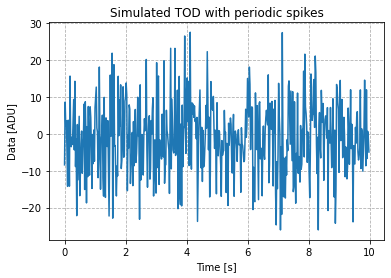

In [11]:
# Generation of a 1 Hz periodic signal
spike = square(time % 1.0)
# Construction of the final signal
data = noise + spike

pl.plot(time[:500], data[:500])
pl.xlabel("Time [s]")
pl.ylabel("Data [ADU]")
pl.title("Simulated TOD with periodic spikes")
pl.grid(True, which="both", linestyle="--")

In [12]:
spec_inst = spectrum.Spectrum()
spec_inst.spectrum_type[0] = 'PSD'  # Calculate power spectral density
spec_inst.remove_drift[0] = True    # If True remove the mean value
spec_inst.welch[0] = True           # If True apply Welch windowing with segments of length samp_freq/lowfreq[0]
spec_inst.lowfreq[0] = 1e-3         # Default value 

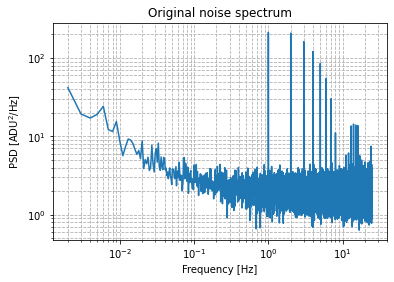

In [13]:
# Noise PSD before spike removal
spec = spec_inst.spectrum(data, fs)

pl.loglog(spec["frequencies"], spec["amplitudes"])
pl.xlabel("Frequency [Hz]")
pl.ylabel(r"PSD [ADU$^2$/Hz]")
pl.title("Original noise spectrum")
pl.grid(True, which="both", linestyle="--")

In [14]:
# Identification of spikes in the noise PSD
spikes = find_spikes(spec["frequencies"], spec["amplitudes"], window_points=50, threshold_sigma=4.5)

print("Frequencies at which spikes are detected in the original PSD:")
print(spikes)

Frequencies at which spikes are detected in the original PSD:
[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 13.0, 14.0, 15.0, 16.0]


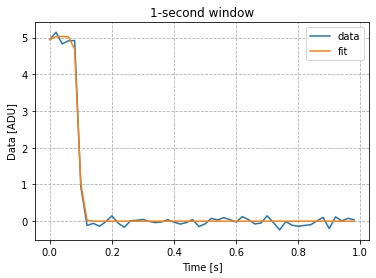

In [15]:
# Fit and removal of the 1 Hz periodic signal
time_window, spike_avg, spike_fit, data_cleaned = remove_spikes(data, time, window_sec=1)

pl.plot(time_window, spike_avg, label="data")
pl.plot(time_window, spike_fit, label="fit")
pl.xlabel("Time [s]")
pl.ylabel("Data [ADU]")
pl.title("1-second window")
pl.grid(True, which="both", linestyle="--")
pl.legend()

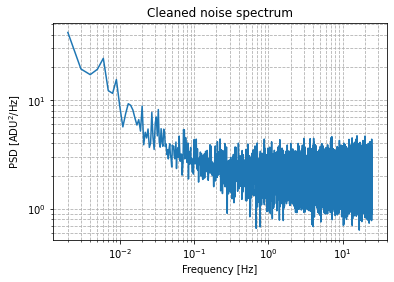

In [16]:
# Noise PSD after spike removal
spec_clean = spec_inst.spectrum(data_cleaned, fs)

pl.loglog(spec_clean["frequencies"], spec_clean["amplitudes"])
pl.xlabel("Frequency [Hz]")
pl.ylabel(r"PSD [ADU$^2$/Hz]")
pl.title("Cleaned noise spectrum")
pl.grid(True, which="both", linestyle="--")

## Application to real TOD from a single detector
In this section, I apply the `remove_spikes` function to demodulated and double-demodulated data acquired from a single detector.

In [17]:
file = cryo_1   # Choose the file
pol = "POL_Y3"     # Choose the polarimeter
det = "U2"         # Choose the detector
data_type = "DEM"  # Choose the data type

In [18]:
# Loads DEM data from one detector of a given polarimeter
with DataFile(file) as my_data:
    time, data = my_data.load_sci(pol, data_type, det)
time = Time(time).unix - Time(time).unix[0]

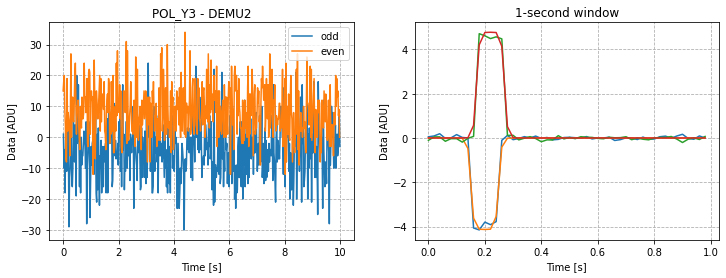

In [19]:
# Fit and removal of the 1 Hz periodic signal in the even and odd samples of the demodulated data
time_window_e, spike_avg_e, spike_fit_e, data_cleaned_e = remove_spikes(data[::2], time[::2], window_sec=1)
time_window_o, spike_avg_o, spike_fit_o, data_cleaned_o = remove_spikes(data[1::2], time[1::2], window_sec=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(time[1::2][:500], data[1::2][:500], label="odd") 
axes[0].plot(time[::2][:500], data[::2][:500], label="even") 
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Data [ADU]")
axes[0].set_title(f"{pol} - {data_type}{det}")
axes[0].grid(True, which="both", linestyle="--")
axes[0].legend()

axes[1].plot(time_window_o, spike_avg_o)
axes[1].plot(time_window_o, spike_fit_o)
axes[1].plot(time_window_e, spike_avg_e)
axes[1].plot(time_window_e, spike_fit_e)
axes[1].set_xlabel("Time [s]") 
axes[1].set_ylabel("Data [ADU]")
axes[1].set_title("1-second window")
axes[1].grid(True, which="both", linestyle="--")

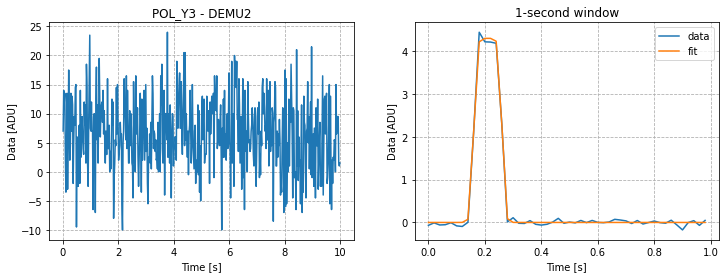

In [20]:
# Fit and removal of the 1 Hz periodic signal in the double-demodulated data
time_dem = average_time(time)
data_dem = double_dem(data)

time_window, spike_avg, spike_fit, data_cleaned = remove_spikes(data_dem, time_dem, window_sec=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(time_dem[:500], data_dem[:500])  
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Data [ADU]")
axes[0].set_title(f"{pol} - {data_type}{det}")
axes[0].grid(True, which="both", linestyle="--")

axes[1].plot(time_window, spike_avg, label="data")
axes[1].plot(time_window, spike_fit, label="fit")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Data [ADU]")
axes[1].set_title("1-second window")
axes[1].grid(True, which="both", linestyle="--")
axes[1].legend()

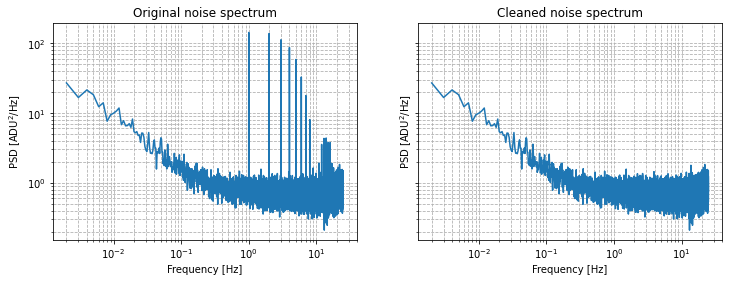

In [21]:
# Comparison of TOD noise PSDs before and after 1 Hz spike removal

# Calculate sampling frequency
T = np.mean(np.diff(time_dem)) 
samp_freq = 1 / T 

# Compute the noise spectrum
spec_dem1 = spec_inst.spectrum(data_dem, samp_freq)
spec_dem2 = spec_inst.spectrum(data_cleaned, samp_freq)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].loglog(spec_dem1["frequencies"], spec_dem1["amplitudes"])  
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel(r"PSD [ADU$^2$/Hz]")
axes[0].set_title("Original noise spectrum")
axes[0].grid(True, which="both", linestyle="--")

axes[1].loglog(spec_dem2["frequencies"], spec_dem2["amplitudes"])
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel(r"PSD [ADU$^2$/Hz]")
axes[1].set_title("Cleaned noise spectrum")
axes[1].grid(True, which="both", linestyle="--")

In [22]:
# Identification of spikes in the noise PSD
spikes = find_spikes(spec_dem1["frequencies"], spec_dem1["amplitudes"], window_points=50, threshold_sigma=4.5)

print("Frequencies at which spikes are detected in the original PSD:")
print(spikes)

Frequencies at which spikes are detected in the original PSD:
[0.999999999990397, 1.999999999980794, 2.999999999971191, 3.999999999961588, 4.999999999951985, 5.999999999942382, 6.999999999932779, 7.999999999923176, 11.999999999884764, 12.999999999875161, 13.999999999865558, 14.999999999855955]
